# Import

In [206]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error


# EDA 

## User Data

In [31]:
users = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/u.data',  sep='\t', header=None)
columns_renamed = ['user_id', 'item_id', 'rating', 'timestamp']
users.columns = columns_renamed
users

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


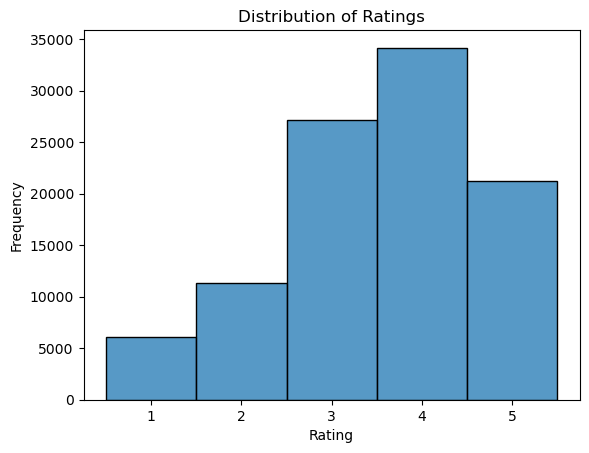

In [ ]:
#plot histogram
sns.histplot(users['rating'], bins=range(6), edgecolor='black', discrete=True)

# set x axis labels
plt.xticks([ 1, 2, 3, 4, 5])

# label and title
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

#### Ratings Per User

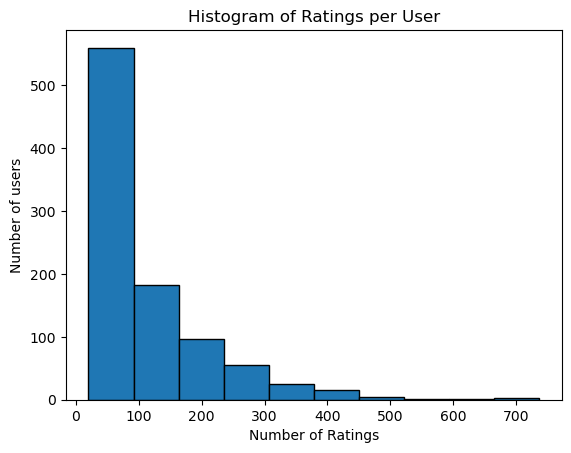

In [76]:
# plot of ratings
user_rating_counts = users.groupby('user_id').size().reset_index(name='count')

plt.hist(user_rating_counts['count'], edgecolor='black')

plt.title("Histogram of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of users")

plt.show()


## Item Data

In [86]:
items = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/u.item', delimiter='|', dtype=None,encoding='latin-1', header=None)
columns_renamed = [
    "movie_id", "movie_title", "release_date", "video_release_date", "IMDb_URL",
    "unknown", "action", "adventure", "animation", "childrens", "comedy", "crime",
    "documentary", "drama", "fantasy", "film_noir", "horror", "musical", "mystery",
    "romance", "sci_fi", "thriller", "war", "western"
]
items.columns = columns_renamed
items

,movie_id,movie_title,release_date,video_release_date,IMDb_URL,unknown,action,adventure,animation,childrens,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# cleaning
items.drop(columns=['video_release_date'], inplace=True)

In [89]:
items

,movie_id,movie_title,release_date,IMDb_URL,unknown,action,adventure,animation,childrens,comedy,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1678,1679,B. Monkey (1998),06-Feb-1998,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1679,1680,Sliding Doors (1998),01-Jan-1998,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1680,1681,You So Crazy (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


#### Handling NAN values

In [93]:
items.isna().sum()

movie_id        0
movie_title     0
release_date    1
IMDb_URL        3
unknown         0
action          0
adventure       0
animation       0
childrens       0
comedy          0
crime           0
documentary     0
drama           0
fantasy         0
film_noir       0
horror          0
musical         0
mystery         0
romance         0
sci_fi          0
thriller        0
war             0
western         0
dtype: int64

In [103]:
# 1 nan value in release_date and 3 in Imdb_url
nan_rows = items[items.isna().any(axis=1)]
nan_rows

,movie_id,movie_title,release_date,IMDb_URL,unknown,action,adventure,animation,childrens,comedy,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
266,267,unknown,NaN,NaN,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1357,1358,The Deadly Cure (1996),16-Sep-1996,NaN,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1358,1359,Boys in Venice (1996),24-Sep-1996,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [110]:
print(type(items['IMDb_URL'][0]))
print(type(items['release_date'][0]))

<class 'str'>
<class 'str'>


In [112]:
items.iloc[266] 

movie_id            267
movie_title     unknown
release_date        NaN
IMDb_URL            NaN
unknown               1
action                0
adventure             0
animation             0
childrens             0
comedy                0
crime                 0
documentary           0
drama                 0
fantasy               0
film_noir             0
horror                0
musical               0
mystery               0
romance               0
sci_fi                0
thriller              0
war                   0
western               0
Name: 266, dtype: object

In [113]:
# just drop the unkown movie, no date, no genres --> doing nothing 
items = items[items['movie_id'] != 267]

In [118]:
# 1357, 1358 movie ids --> no imdb url
items.loc[items['movie_id'] == 1358,'IMDb_URL'] = 'no_url'
items.loc[items['movie_id'] == 1358]['IMDb_URL']

1357    no_url
Name: IMDb_URL, dtype: object

In [119]:
items.loc[items['movie_id'] == 1359,'IMDb_URL'] = 'no_url'
items.loc[items['movie_id'] == 1358]['IMDb_URL']

1357    no_url
Name: IMDb_URL, dtype: object

#### Graphs

In [129]:
# number of each type of film
genre_columns = ["unknown", "action", "adventure", "animation", "childrens", "comedy", "crime",
    "documentary", "drama", "fantasy", "film_noir", "horror", "musical", "mystery",
    "romance", "sci_fi", "thriller", "war", "western"]

genre_sums = items[genre_columns].sum()
genre_sums = genre_sums.reset_index()
genre_sums.columns = ['genre', 'count']
genre_sums

,genre,count
0,unknown,1
1,action,251
2,adventure,135
3,animation,42
4,childrens,122
5,comedy,505
6,crime,109
7,documentary,50
8,drama,725
9,fantasy,22


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


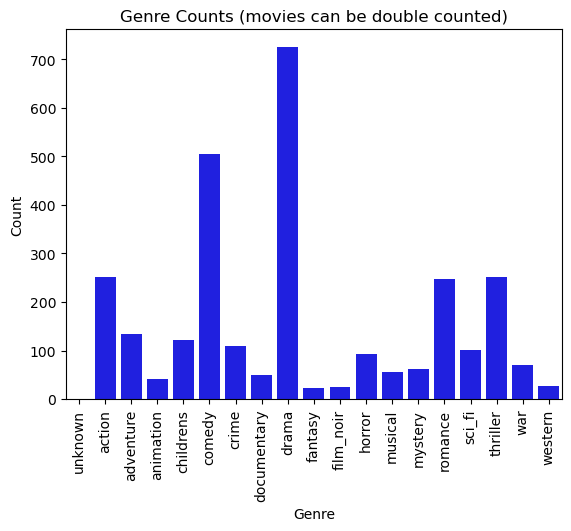

In [ ]:
# bar plot
sns.barplot(x='genre', y='count', data=genre_sums, color='blue')
plt.xticks(rotation=90)  
plt.title('Genre Counts (movies can be double counted)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

In [140]:
# ratings per year
items['release_date'] = pd.to_datetime(items['release_date'], format='%d-%b-%Y')
items

/var/folders/zv/4f9cw9vs6tjbvz5bh2k07w_40000gn/T/ipykernel_35848/2977759970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  items['release_date'] = pd.to_datetime(items['release_date'], format='%d-%b-%Y')


,movie_id,movie_title,release_date,IMDb_URL,unknown,action,adventure,animation,childrens,comedy,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),1995-01-01,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),1995-01-01,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),1995-01-01,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),1995-01-01,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),1995-01-01,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),1998-02-06,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1678,1679,B. Monkey (1998),1998-02-06,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1679,1680,Sliding Doors (1998),1998-01-01,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1680,1681,You So Crazy (1994),1994-01-01,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


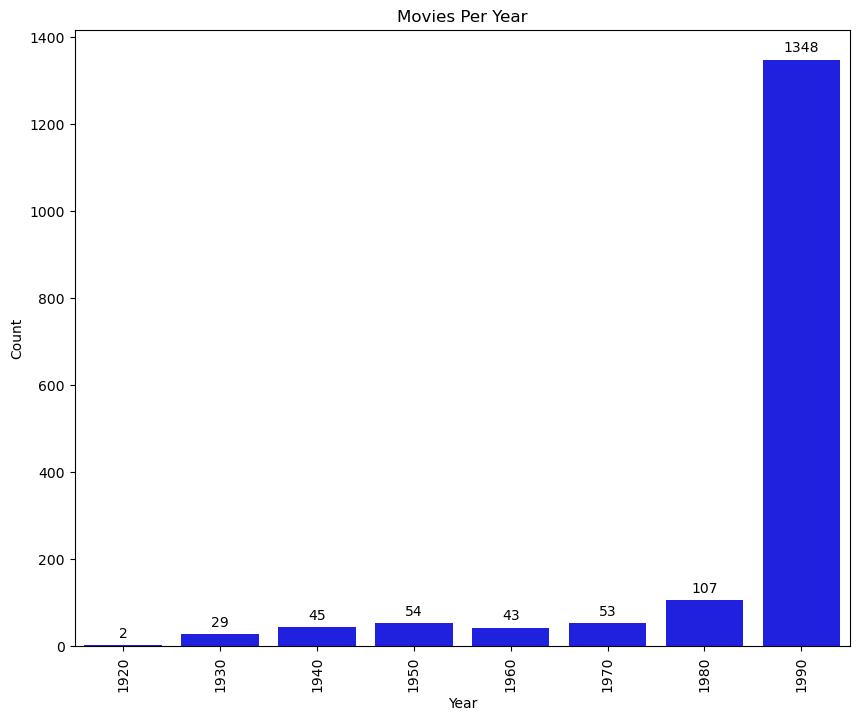

In [158]:
# convert to year
items.loc[:,'release_year'] = items['release_date'].dt.year

# get decade
items.loc[:,'decade'] = (items['release_year'] // 10) * 10

# group by year
movies_by_decade = items.groupby('decade')['movie_id'].count().reset_index()
movies_by_decade.columns = ['decade', 'count']
movies_by_decade

## plot bar chart
plt.figure(figsize=(10, 8))
plot = sns.barplot(x='decade', y='count', data=movies_by_decade, color='blue')

# add text labels for count
for i in plot.containers:
    plot.bar_label(i, label_type='edge', padding=3)

plt.xticks(rotation=90)  
plt.title('Movies Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


# Recommender Model

## Preprocess

In [159]:
# thus I want a matrix with 943 rows, 1682 columns
user_ids = sorted(users['user_id'].unique())
item_ids = sorted(users['item_id'].unique())

# matrix[i][j] is rating for person i, movie j
print(user_ids[0], user_ids[942])
print(item_ids[0], item_ids[1581])
            
# map to indices
user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_id_to_index = {item_id: idx for idx, item_id in enumerate(item_ids)}

# create empty matrix
matrix = np.zeros((len(user_ids), len(item_ids)))

# fill matrix
for row in users.itertuples():
    user_idx = user_id_to_index[row.user_id]
    item_idx = item_id_to_index[row.item_id]
    matrix[user_idx][item_idx] = row.rating

print(len(matrix))
print(len(matrix[0]))


1 943
1 1582
943
1682


In [ ]:
## NORMALIZATION STEP ##

# compute the row means
# row_means = np.true_divide(matrix.sum(1), (matrix != 0).sum(1))

# # Step 2: Subtract row mean only where rating is non-zero
# norm_matrix = matrix.copy().astype(float)
# for i in range(len(norm_matrix)):
#     for j in range(len(norm_matrix[0])):
#         if norm_matrix[i, j] != 0:
#             norm_matrix[i, j] -= row_means[i]

## Set up the model

In [261]:
### input param ###
num_neighbors = 15
#################

knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=num_neighbors)
knn.fit(matrix)

params = knn.get_params()

predicted_ratings_matrix = np.zeros((len(matrix), len(matrix[0])))

for user_id in range(len(matrix)):
    distances, indices = knn.kneighbors(matrix[user_id].reshape(1, -1))
    neighbors_ratings = matrix[indices.flatten()]
    predicted_ratings = neighbors_ratings.mean(axis=0)
    predicted_ratings_matrix[user_id] = predicted_ratings


## get results

In [262]:
all_actual = []
all_pred = []

for user_id in range(len(matrix)):
    # compare items that have actually been rated by the user
    rated_items = np.where(matrix[user_id] != 0)[0]
    actual = matrix[user_id][rated_items]
    predicted = predicted_ratings_matrix[user_id][rated_items]

    all_actual.extend(actual)
    all_pred.extend(predicted)

system_rmse = np.sqrt(mean_squared_error(all_actual, all_pred))

In [263]:
def get_user_results(target_user):
    # filter to get items that the user hasnt rated
    unrated_items = np.where(matrix[target_user] == 0)[0]

    # sort the ratings 
    recommended_indices = np.argsort(predicted_ratings_matrix[target_user][unrated_items])[::-1][:10]
    top_items = unrated_items[recommended_indices]

    # compute rmse for the rated items
    rated_items = np.where(matrix[target_user] != 0)[0]
    actual = matrix[target_user][rated_items]
    predicted = predicted_ratings_matrix[target_user][rated_items]
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # get the rows needed for the final df
    selected_rows = items.loc[top_items]
    selected_rows['predicted_rating'] = predicted_ratings_matrix[target_user][top_items]
    selected_rows = selected_rows[['movie_id', 'movie_title', 'predicted_rating']]
    selected_rows.reset_index(inplace=True, drop=True)

    return selected_rows, rmse



## Test different n_neighbors param
**WARNING**: This was run specifically with the num_neighbors param above set, it the above code was re run to test different n_neighbors param values. Therefore, if you want to recreate the results for the following code and each test for num_neighbors, start at the "set up model" header and set the intended num_neighbors param

### n_neighbors = 5
run time to get predictions: 7.4s


In [243]:
# set the target user
target_user = 12

# get the intended information for the specified user
top_ten, rmse = get_user_results(target_user)

# print recommendations with title and predicted_rating
print(f"number of neighbors: {num_neighbors}")
print(f"rmse for the recommender system: {system_rmse}")
print(f"rmse for the user: {rmse}")
print(f"recommendations for user: {target_user}")
top_ten

number of neighbors: 5
rmse for the recommender system: 1.6412426999076035
rmse for the user: 1.670649329569176
recommendations for user: 12


,movie_id,movie_title,predicted_rating
0,134,Citizen Kane (1941),3.6
1,496,It's a Wonderful Life (1946),3.6
2,479,Vertigo (1958),3.4
3,192,Raging Bull (1980),3.2
4,528,"Killing Fields, The (1984)",3.2
5,724,Circle of Friends (1995),3.0
6,942,What's Love Got to Do with It (1993),3.0
7,133,Gone with the Wind (1939),3.0
8,582,"Piano, The (1993)",3.0
9,956,Nobody's Fool (1994),2.8


### n_neighbors = 2
Notes:
- run time to get predictions: 8.1s
- the overall rmse of the system is lower, but for each user, the highest predicted rating hovers around a 2 - 2.5



In [252]:
# set the target user
target_user = 12

# get the intended information for the specified user
top_ten, rmse = get_user_results(target_user)

# print recommendations with title and predicted_rating
print(f"number of neighbors: {num_neighbors}")
print(f"rmse for the recommender system: {system_rmse}")
print(f"rmse for the user: {rmse}")
print(f"recommendations for user: {target_user}")
top_ten

number of neighbors: 2
rmse for the recommender system: 1.213703011448847
rmse for the user: 1.173776627952288
recommendations for user: 12


,movie_id,movie_title,predicted_rating
0,479,Vertigo (1958),2.5
1,1463,"Boys, Les (1997)",2.5
2,611,Laura (1944),2.5
3,134,Citizen Kane (1941),2.5
4,513,"Third Man, The (1949)",2.5
5,1121,"Umbrellas of Cherbourg, The (Parapluies de Che...",2.5
6,490,To Catch a Thief (1955),2.0
7,206,Akira (1988),2.0
8,1449,Pather Panchali (1955),2.0
9,1186,"Inkwell, The (1994)",2.0


### n_neighbors = 7

Notes:
- time to run to get predictions: 5.3s
- rmse is higher than n_neighbors at 2 and 5, but predicted ratings are higher than n_neighbors both 2 and 5

In [256]:
# set the target user
target_user = 12

# get the intended information for the specified user
top_ten, rmse = get_user_results(target_user)

# print recommendations with title and predicted_rating
print(f"number of neighbors: {num_neighbors}")
print(f"rmse for the recommender system: {system_rmse}")
print(f"rmse for the user: {rmse}")
print(f"recommendations for user: {target_user}")
top_ten

number of neighbors: 7
rmse for the recommender system: 1.7312064921225736
rmse for the user: 1.786998639649195
recommendations for user: 12


,movie_id,movie_title,predicted_rating
0,134,Citizen Kane (1941),3.857143
1,192,Raging Bull (1980),3.714286
2,479,Vertigo (1958),3.714286
3,496,It's a Wonderful Life (1946),3.428571
4,528,"Killing Fields, The (1984)",3.428571
5,642,"Grifters, The (1990)",3.428571
6,513,"Third Man, The (1949)",3.142857
7,133,Gone with the Wind (1939),3.142857
8,942,What's Love Got to Do with It (1993),3.142857
9,648,"Quiet Man, The (1952)",3.000000


### n_neighbors = 9
Notes:
- time to get predictions: 6.0s
- higher predicted ratings and highest system wide rmse

In [260]:
# set the target user
target_user = 12

# get the intended information for the specified user
top_ten, rmse = get_user_results(target_user)

# print recommendations with title and predicted_rating
print(f"number of neighbors: {num_neighbors}")
print(f"rmse for the recommender system: {system_rmse}")
print(f"rmse for the user: {rmse}")
print(f"recommendations for user: {target_user}")
top_ten

number of neighbors: 9
rmse for the recommender system: 1.7874230364161448
rmse for the user: 1.8856129359204576
recommendations for user: 12


,movie_id,movie_title,predicted_rating
0,134,Citizen Kane (1941),4.000000
1,479,Vertigo (1958),3.888889
2,496,It's a Wonderful Life (1946),3.666667
3,528,"Killing Fields, The (1984)",3.555556
4,133,Gone with the Wind (1939),3.444444
5,192,Raging Bull (1980),3.333333
6,642,"Grifters, The (1990)",3.333333
7,648,"Quiet Man, The (1952)",3.222222
8,203,Unforgiven (1992),3.222222
9,513,"Third Man, The (1949)",2.888889


### n_neighbors = 15


In [264]:
# set the target user
target_user = 12

# get the intended information for the specified user
top_ten, rmse = get_user_results(target_user)

# print recommendations with title and predicted_rating
print(f"number of neighbors: {num_neighbors}")
print(f"rmse for the recommender system: {system_rmse}")
print(f"rmse for the user: {rmse}")
print(f"recommendations for user: {target_user}")
top_ten

number of neighbors: 15
rmse for the recommender system: 1.8840893114004265
rmse for the user: 2.017360017337699
recommendations for user: 12


,movie_id,movie_title,predicted_rating
0,479,Vertigo (1958),4.066667
1,134,Citizen Kane (1941),4.066667
2,496,It's a Wonderful Life (1946),4.000000
3,133,Gone with the Wind (1939),3.333333
4,203,Unforgiven (1992),3.266667
5,136,Mr. Smith Goes to Washington (1939),3.133333
6,192,Raging Bull (1980),3.066667
7,521,"Deer Hunter, The (1978)",2.933333
8,633,"Christmas Carol, A (1938)",2.866667
9,47,Ed Wood (1994),2.866667
